<h1>
    <center>
        BV Regime NN Pipeline<br><br>Using a Trained Model and Analysing the Results
    </center>
</h1>

----
- Laique M. Djeutchouang

----
# Overview

This notebook loads a model trained by [`pipeline.py`](pipeline.py), runs
probabilistic inference, and works through the analysis the outputs are built
for.

## What the model produces

It never assigns a single regime outright. For
every `(time, lat, lon)` cell it emits a probability distribution over the BV
regimes, from which four fields are derived:

| Variable | Dims | Meaning |
| --- | --- | --- |
| `regime_prob` | `(time, lat, lon, regime)` | Probability of each regime |
| `regime_entropy` | `(time, lat, lon)` | Normalised Shannon entropy — `0` confident, `1` maximally ambiguous |
| `regime_pred` | `(time, lat, lon)` | Most likely regime (argmax) |
| `regime_confidence` | `(time, lat, lon)` | Probability of that most likely regime |

The two that matter together are `regime_pred` and `regime_entropy`: the regime
map is only trustworthy where entropy is low, and the high-entropy regions are
themselves a result — they mark transitional dynamics.

## Prerequisites

The `slvp_nn` environment (see
[`environment.yml`](environment.yml) and the *Environment* section of
[`README.md`](README.md)). Start the kernel from it:

```bash
mamba activate slvp_nn
python -m ipykernel install --user --name slvp_nn --display-name "Python (slvp_nn)"
```

# Setup Requirements

## Import Packages

In [27]:
import os
import sys
import json
import subprocess
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# pipeline.py lives next to this notebook; fall back to the repo path when the
# notebook is opened from somewhere else.
NN_DIR = Path.cwd() if (Path.cwd() / "pipeline.py").exists() else Path("/home/djeutsch/Projects/seaLevelRegimes/nn")
if str(NN_DIR) not in sys.path:
    sys.path.insert(0, str(NN_DIR))

import pipeline
from pipeline import (BVBRegimeMLP, ModelConfig, TrainConfig,
                      open_dataset, BVB_TERMS, LABEL_VAR)

pipeline.setup_logging(verbose=False)   # the pipeline logs to stdout

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "figure.autolayout": True})

# Zarr 3 warns on every consolidated write; the pipeline does that per block.
warnings.filterwarnings("ignore", message=".*Consolidated metadata.*")

# Cartopy makes the maps geographic; everything still works without it.
# Catch broadly: a cartopy that is installed but misconfigured (no PROJ data
# directory, say) raises at import time with something other than ImportError.
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter
    ccrs.PlateCarree()          # touch PROJ now rather than mid-figure
    HAS_CARTOPY = True
except Exception as _err:
    HAS_CARTOPY = False
    print(f"cartopy unavailable ({type(_err).__name__}) - falling back to lat/lon axes")

print(f"pipeline   : {NN_DIR / 'pipeline.py'}")
print(f"BVB terms  : {BVB_TERMS}")
print(f"label var  : {LABEL_VAR}")
print(f"cartopy    : {'yes' if HAS_CARTOPY else 'no (plain lat/lon axes)'}")

pipeline   : /home/djeutsch/Projects/seaLevelRegimes/nn/pipeline.py
BVB terms  : ['beta_V', 'BPT', 'Mass_flux', 'eta_dt', 'Curl_dudt', 'Curl_taus', 'Curl_taub', 'Curl_Adv', 'Curl_diff']
label var  : bvb_regime
cartopy    : yes


## Customized Tools

In [24]:
### Define plotting properties 
from string import ascii_lowercase as asci

def number_figures(axes, pos=None, labels=asci, braces=True, **text_kwargs):

    depth = lambda L: isinstance(L, list) and max(map(depth, L)) + 1

    if pos is None:
        pos = [[0.99, 0.93]] * len(axes)
    elif (depth(pos) == 1) & (len(pos) == 2):
        pos = [list(pos)] * len(axes)
    elif (depth(pos) != 2) & (len(pos) != len(axes)):
        raise (Exception, 'check the position is the right format')
    
    for c, ax in enumerate(axes):
        x0, x1 = ax.get_xlim()
        y0, y1 = ax.get_ylim()

        w = x1 - x0
        h = y1 - y0
        x = x0 + w * pos[c][0]
        y = y0 + h * pos[c][1]

        t = '%s' % labels[c]
        if braces:
            t = '(%s)' % (t)
        ax.text(x, y, t, **text_kwargs)
          

def add_map_features(ax, draw_countries=False, draw_labels=False, right=False):
    # Add coastlines
    ax.coastlines(color="lightgrey", linewidth=0.1125)

    # Add land and states
    ax.add_feature(cfeature.LAND, facecolor='darkgrey', edgecolor='lightgrey', linewidth=0.15, zorder=-1)
    if draw_countries:
        ax.add_feature(cfeature.BORDERS, linewidth=0.125, alpha=0.25, edgecolor='black')
    
    # Create gridlines and specify the coordinate system
    gl = ax.gridlines(crs=ccrs.PlateCarree(), dms=True, draw_labels=draw_labels,
                      linewidth=0.15, color='black', alpha=0.25, linestyle='--')
    
    if draw_labels:
        # Customize the labels format
        gl.xformatter = LongitudeFormatter()
        gl.yformatter = LatitudeFormatter()
        
        # Optional: Customize label appearance
        gl.xlabel_style = {'size': 8, 'color': 'black'}
        gl.ylabel_style = {'size': 8, 'color': 'black'}
        
        # Remove default labels on the top and right sides
        gl.top_labels = False
        gl.right_labels = right


def add_grid_borders(ax, land=False, borders=True, draw_labels=True, right=False):
    # Create gridlines and specify the coordinate system
    gl = ax.gridlines(crs=ccrs.PlateCarree(), dms=True, draw_labels=draw_labels,
                      linewidth=0.15, color='black', alpha=0.25, linestyle='--')
    if land:
        ax.add_feature(cfeature.LAND, facecolor='darkgrey', edgecolor='lightgrey', linewidth=0.15, zorder=-1)
        
    if borders:
        ax.add_feature(cfeature.BORDERS, linewidth=0.125, alpha=0.25, edgecolor='black')
    
    if draw_labels:
        # Customize the labels format
        gl.xformatter = LongitudeFormatter()
        gl.yformatter = LatitudeFormatter()
        
        # Optional: Customize label appearance
        gl.xlabel_style = {'size': 8, 'color': 'black'}
        gl.ylabel_style = {'size': 8, 'color': 'black'}
        
        # Remove default labels on the top and right sides
        gl.top_labels = False
        gl.right_labels = right




## Configuration

Everything the notebook needs is set here. `BASE_DIR` mirrors `SLVP_BASE_DIR`,
the same root `pipeline.py` and `submit.sh` build their defaults from.

In [63]:
BASE_DIR = Path(os.environ.get("SLVP_BASE_DIR", "/group/maikesgrp/laique/PPAN/CM4X/NN4X"))

# Features + labels, as written for the pipeline.
INPUT_ZARR = BASE_DIR / "inputs" / "global_NN4X_p25_monthly_features_nc15.zarr"

# Where the Slurm runs put their outputs.
OUTDIR = BASE_DIR / "outputs" / "nn"

# Run to analyse. TAG selects the checkpoint and the prediction store.
TAG = "bvb_mlp_h256x128x64x32_k15_2005_2011"
CKPT = OUTDIR / "models" / f"{TAG}.pt"
PRED_STORE = OUTDIR / "predictions" / f"{TAG}_predictions.zarr"

# Inference window: None keeps the whole record.
PREDICT_YEARS = None            # e.g. ("2012", "2014")

DEVICE = "auto"                 # "auto" | "cpu" | "cuda" | "cuda:0"

# Somewhere to write the notebook's own artefacts.
SCRATCH = Path(os.environ.get("SLVP_NB_SCRATCH", BASE_DIR / "outputs/notebook_outputs"))
SCRATCH.mkdir(parents=True, exist_ok=True)

for name, p in [("input", INPUT_ZARR), ("checkpoint", CKPT),
                ("predictions", PRED_STORE), ("scratch", SCRATCH)]:
    print(f"{name:12s} {'OK     ' if p.exists() else 'missing'}  {p}")

input        OK       /group/maikesgrp/laique/PPAN/CM4X/NN4X/inputs/global_NN4X_p25_monthly_features_nc15.zarr
checkpoint   OK       /group/maikesgrp/laique/PPAN/CM4X/NN4X/outputs/nn/models/bvb_mlp_h256x128x64x32_k15_2005_2011.pt
predictions  OK       /group/maikesgrp/laique/PPAN/CM4X/NN4X/outputs/nn/predictions/bvb_mlp_h256x128x64x32_k15_2005_2011_predictions.zarr
scratch      OK       /group/maikesgrp/laique/PPAN/CM4X/NN4X/outputs/notebook_outputs


### Demo fallback

The analysis below needs *a* trained model and *a* dataset. When the real ones
are not on disk yet, the next cell builds a small synthetic dataset with the
same contract `pipeline.open_dataset` enforces — dims `(time, lat, lon)`, the
nine BVB terms, and an integer `bvb_regime` label — and trains a tiny model on
it. That keeps the whole notebook runnable end to end, so you can verify the
environment and the analysis code before the real inputs exist.

`DEMO` is set automatically. Everything after this section is identical in both
modes, so nothing needs editing when the real data arrives.

In [4]:
DEMO = not INPUT_ZARR.exists()

def make_synthetic_store(path, ntime=60, nlat=48, nlon=96, n_regimes=6, seed=0):
    """A small, learnable stand-in for the real feature/label store.

    Deliberately *not* trivially separable. Regime centroids in the
    9-dimensional BVB space overlap, and the observation noise varies smoothly
    in space, so some regions are genuinely harder to classify than others.
    That is what makes the entropy diagnostics in section 7 meaningful: a
    perfectly separable toy would score 100% everywhere and show nothing.
    """
    rng = np.random.default_rng(seed)
    lat = np.linspace(-78, 78, nlat)
    lon = np.linspace(0, 358, nlon)
    time = pd.date_range("2005-01-01", periods=ntime, freq="MS")

    # Latent regime field: smooth in space, slowly varying in time.
    LA, LO = np.meshgrid(np.deg2rad(lat), np.deg2rad(lon), indexing="ij")
    base = (2.2 * np.sin(2 * LA) + 1.6 * np.cos(3 * LO) + 0.9 * np.sin(4 * LA + LO))
    drift = 0.55 * np.sin(2 * np.pi * np.arange(ntime) / 24.0)[:, None, None]
    field = base[None] + drift + 0.25 * rng.standard_normal((ntime, nlat, nlon))
    edges = np.quantile(field, np.linspace(0, 1, n_regimes + 1)[1:-1])
    labels = np.digitize(field, edges).astype(np.float32)   # 0 .. n_regimes-1

    # Overlapping centroids, plus noise that is smoothly harder in some regions.
    centroids = rng.normal(0, 0.9, size=(n_regimes, len(BVB_TERMS)))
    hardness = 0.5 + 0.5 * np.sin(3 * LA) * np.cos(2 * LO)      # [0, 1]
    scale = (0.35 + 1.15 * hardness)[None, :, :, None]
    idx = labels.astype(int)
    feats = centroids[idx] + scale * rng.standard_normal(idx.shape + (len(BVB_TERMS),))

    # Land: a couple of blobs, NaN in every field.
    land = ((np.abs(LA - 0.35) < 0.30) & (np.abs(LO - 2.1) < 0.45)) | \
           ((np.abs(LA + 0.75) < 0.22) & (np.abs(LO - 4.6) < 0.60))
    feats[:, land, :] = np.nan
    labels[:, land] = np.nan

    ds = xr.Dataset(
        {term: (("time", "lat", "lon"), feats[..., j].astype(np.float32))
         for j, term in enumerate(BVB_TERMS)},
        coords={"time": time, "lat": lat, "lon": lon},
    )
    ds[LABEL_VAR] = (("time", "lat", "lon"), labels)
    ds.attrs["note"] = "Synthetic demo data - not physical."
    ds.chunk({"time": 12}).to_zarr(path, mode="w", consolidated=True)
    return path

if DEMO:
    INPUT_ZARR = SCRATCH / "demo_features_labels.zarr"
    OUTDIR = SCRATCH / "demo_outputs"
    TAG = "demo"
    CKPT = OUTDIR / "models" / f"{TAG}.pt"
    PRED_STORE = OUTDIR / "predictions" / f"{TAG}_predictions.zarr"
    N_REGIMES_DEMO = 6
    if not INPUT_ZARR.exists():
        make_synthetic_store(INPUT_ZARR, n_regimes=N_REGIMES_DEMO)
    print(f"DEMO MODE - synthetic data at {INPUT_ZARR}")
else:
    print(f"Using the real dataset at {INPUT_ZARR}")

Using the real dataset at /group/maikesgrp/laique/PPAN/CM4X/NN4X/inputs/global_NN4X_p25_monthly_features_nc15.zarr


### Load the trained model

`from_checkpoint` rebuilds the network, the feature scaler and the training
history from the `.pt` file alone — the architecture never has to be restated.

In demo mode there is no checkpoint, so a small model is trained here first;
the training call is exactly the one from the final section of this notebook.

In [5]:
if not CKPT.exists():
    if not DEMO:
        raise FileNotFoundError(
            f"No checkpoint at {CKPT}.\n"
            "Set TAG to a run that exists, or train one - see the final section.")
    # Demo: a deliberately tiny network, a handful of epochs.
    ds_train = open_dataset(INPUT_ZARR, BVB_TERMS, LABEL_VAR)
    demo = BVBRegimeMLP(ModelConfig(n_regimes=N_REGIMES_DEMO, hidden=(64, 32)),
                        device=DEVICE)
    demo.fit(ds_train, TrainConfig(epochs=12, batch_size=16384, patience=6,
                                   curriculum_warmup=0))
    demo.save(CKPT)
    pipeline.save_history(demo.history, CKPT.with_name(f"{TAG}_history.csv"))
    ds_train.close()

model = BVBRegimeMLP.from_checkpoint(CKPT, device=DEVICE)

print(f"device     : {model.device}")
print(f"features   : {model.config.features}")
print(f"hidden     : {model.config.hidden}")
print(f"n_regimes  : {model.config.n_regimes}")
print(f"label var  : {model.config.label_var}")
print(f"parameters : {sum(p.numel() for p in model.model.parameters()):,}")
print(f"epochs run : {len(model.history['epoch'])}")

INFO - 2026-09-05T04:57:10Z - Checkpoint loaded from /group/maikesgrp/laique/PPAN/CM4X/NN4X/outputs/nn/models/bvb_mlp_h256x128x64x32_k15_2005_2011.pt
device     : cpu
features   : ['beta_V', 'BPT', 'Mass_flux', 'eta_dt', 'Curl_dudt', 'Curl_taus', 'Curl_taub', 'Curl_Adv', 'Curl_diff']
hidden     : (256, 128, 64, 32)
n_regimes  : 15
label var  : bvb_regime
parameters : 47,247
epochs run : 83


`model.config.features` is authoritative. Any dataset you predict on must carry
those variables, and the model applies them **in that order** — the scaler
statistics are positional.

In [6]:
scaler_table = pd.DataFrame({
    "feature": model.config.features,
    "train_mean": model.scaler.mean_,
    "train_std": model.scaler.scale_,
}).set_index("feature")
scaler_table

,train_mean,train_std
feature,,
beta_V,2.574491e-13,1.446136e-09
BPT,-5.549920e-12,1.218800e-08
Mass_flux,7.292361e-14,7.621495e-12
eta_dt,2.955098e-11,7.743875e-09
Curl_dudt,1.043311e-13,1.941729e-09
Curl_taus,-7.347730e-12,3.528564e-10
Curl_taub,-5.032083e-12,2.807538e-09
Curl_Adv,-4.733260e-14,6.993706e-09
Curl_diff,-1.149372e-11,6.904153e-09


# Analysis of Results

## Did training go well?

The history travels inside the checkpoint, so the curves are available without
opening the CSV.

Read **`val_balanced_accuracy`**, not `val_accuracy`, whenever the rare regimes
matter: the plain accuracy is dominated by whichever regimes cover the most
ocean, so a model that ignores the rare ones entirely can still score well on
it. `metric` is the dual criterion the scheduler and the early stopping both
act on (validation loss plus `lambda_entropy` x validation entropy).

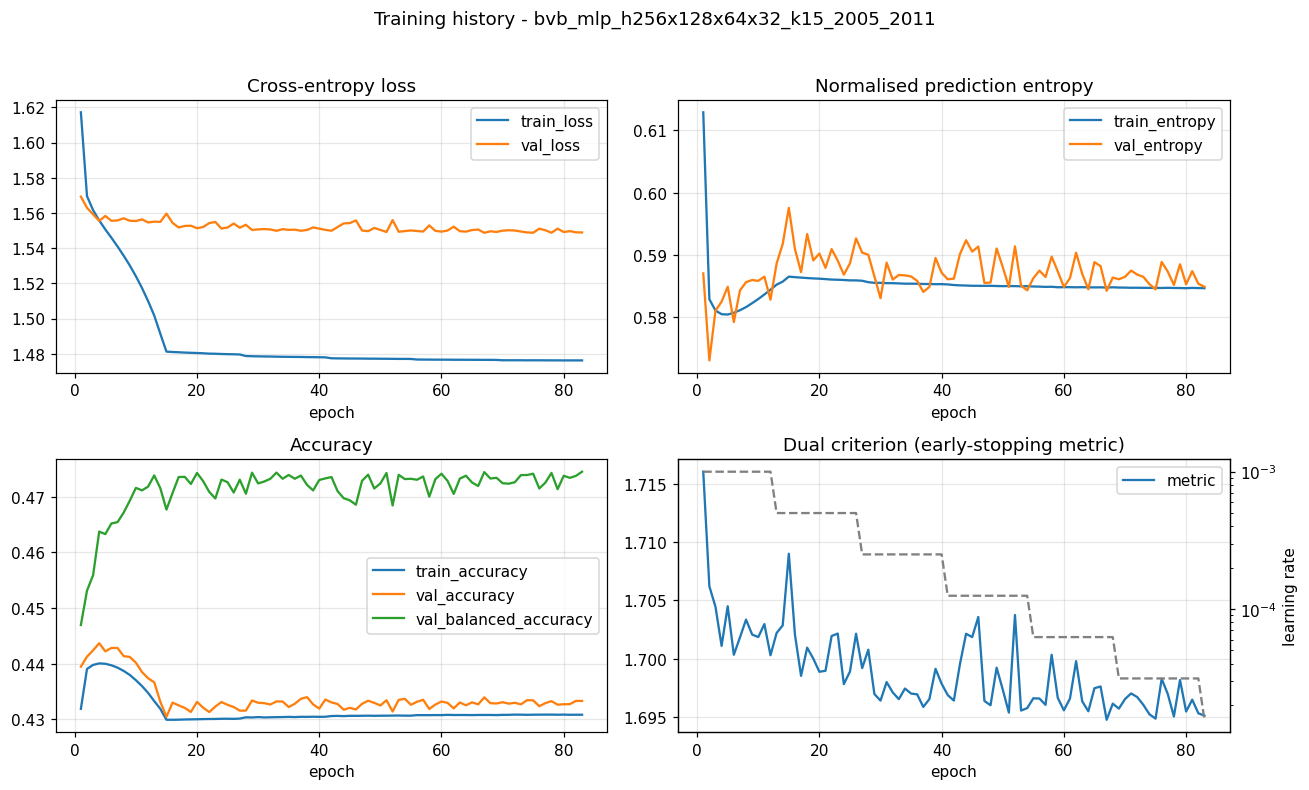

best epoch (lowest dual criterion): 67


epoch,67
lr,0.000063
train_loss,1.476493
val_loss,1.548712
train_entropy,0.584768
val_entropy,0.584249
train_accuracy,0.430780
val_accuracy,0.433946
val_balanced_accuracy,0.474440
metric,1.694774


In [7]:
hist = pd.DataFrame(model.history).set_index("epoch")

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
hist[["train_loss", "val_loss"]].plot(ax=axes[0, 0], title="Cross-entropy loss")
hist[["train_entropy", "val_entropy"]].plot(ax=axes[0, 1],
                                            title="Normalised prediction entropy")
hist[["train_accuracy", "val_accuracy", "val_balanced_accuracy"]].plot(
    ax=axes[1, 0], title="Accuracy")
hist[["metric"]].plot(ax=axes[1, 1], title="Dual criterion (early-stopping metric)")
ax2 = axes[1, 1].twinx()
hist["lr"].plot(ax=ax2, color="grey", ls="--", legend=False)
ax2.set_yscale("log"); ax2.set_ylabel("learning rate"); ax2.grid(False)
for ax in axes.flat:
    ax.set_xlabel("epoch")
fig.suptitle(f"Training history - {TAG}", y=1.02)
plt.show()

best = hist["metric"].idxmin()
print(f"best epoch (lowest dual criterion): {best}")
hist.loc[[best]].T

A gap that keeps widening between `train_loss` and `val_loss` is the usual
overfitting signature; because the split is chronological rather than random,
it can also mean the validation months are simply a different regime era than
the training months. Compare the two readings before reacting to one.

## Inference

`open_dataset` applies the same checks the Slurm job does: the feature
variables must be present, the dims must be `(time, lat, lon)`, and the year
range is applied here rather than afterwards.

Two ways to run the model, and the choice is about memory, not about results:

* **`model.predict(ds)`** holds the whole answer in memory. Fine for a few
  years of a coarse grid.
* **`model.predict_to_store(ds, path)`** streams the inference in blocks of
  months and appends each to a Zarr store. This is what the Slurm job uses, and
  the only sane option for a long record or a fine grid — its memory cost does
  not scale with the length of the record.

If the job already wrote a prediction store, skip both and open it.

In [8]:
if PRED_STORE.exists():
    print(f"Opening the existing prediction store: {PRED_STORE}")
    pred = xr.open_zarr(PRED_STORE, chunks=None)
else:
    ds_new = open_dataset(INPUT_ZARR,
                          features=model.config.features,
                          label_var=None,          # labels are not needed to predict
                          years=PREDICT_YEARS)
    model.predict_to_store(ds_new, PRED_STORE, entropy_unit="fraction",
                           time_chunk=12)
    ds_new.close()
    pred = xr.open_zarr(PRED_STORE, chunks=None)

# The entropy unit is recorded in the attributes; normalise to [0, 1] so every
# threshold below means the same thing whichever unit the run used.
ENT_SCALE = 100.0 if pred.attrs.get("entropy_unit") == "percent" else 1.0
entropy = pred["regime_entropy"] / ENT_SCALE

K = int(pred.sizes["regime"])
print(f"\n{pred.sizes}")
print(f"regimes: {K} | entropy unit: {pred.attrs.get('entropy_unit', 'fraction')}")
pred

Opening the existing prediction store: /group/maikesgrp/laique/PPAN/CM4X/NN4X/outputs/nn/predictions/bvb_mlp_h256x128x64x32_k15_2005_2011_predictions.zarr

Frozen({'time': 120, 'lat': 1080, 'lon': 1440, 'regime': 15})
regimes: 15 | entropy unit: fraction


<xarray.Dataset> Size: 13GB
Dimensions:            (time: 120, lat: 1080, lon: 1440, regime: 15)
Coordinates:
  * time               (time) object 960B 2005-01-16 12:00:00 ... 2014-12-16 ...
  * lat                (lat) float64 9kB -89.92 -89.75 -89.58 ... 89.75 89.92
  * lon                (lon) float64 12kB -179.9 -179.6 -179.4 ... 179.6 179.9
  * regime             (regime) int64 120B 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15
Data variables:
    regime_confidence  (time, lat, lon) float32 746MB ...
    regime_entropy     (time, lat, lon) float32 746MB nan nan ... 0.3916 0.3916
    regime_pred        (time, lat, lon) float32 746MB ...
    regime_prob        (time, lat, lon, regime) float32 11GB ...
Attributes:
    description:   In this BV regime classification problem, a probabilistic ...
    entropy_unit:  fraction
    features:      beta_V, BPT, Mass_flux, eta_dt, Curl_dudt, Curl_taus, Curl...
    n_regimes:     15

### Labels, if this dataset has them

Inference does not need labels, but every skill metric does. Where the dataset
carries `bvb_regime`, the notebook scores the predictions; where it does not,
the scoring sections are skipped and the descriptive analysis still runs.

In [9]:
try:
    ds_lab = open_dataset(INPUT_ZARR, features=[], label_var=model.config.label_var,
                          years=PREDICT_YEARS)
    truth = ds_lab[model.config.label_var].sel(time=pred["time"])
    HAS_LABELS = True
    print(f"Labels found: {model.config.label_var}")
except (KeyError, FileNotFoundError) as err:
    truth, HAS_LABELS = None, False
    print(f"No labels available - skill sections will be skipped.\n  ({err})")

INFO - 2026-09-05T05:01:18Z - Loaded global_NN4X_p25_monthly_features_nc15.zarr | time: 2005-01-16 -> 2014-12-16 (120 steps) | grid: 1080 x 1440
Labels found: bvb_regime


## Outputs Sanity checks

Cheap, and they catch the failures that otherwise show up as a puzzling map
several cells later: a scaler mismatch, a truncated store, a broken land mask.

In [12]:
ocean = pred["regime_prob"].notnull().any("regime")     # (time, lat, lon)
n_ocean = int(ocean.sum())

prob_sum = pred["regime_prob"].sum("regime").where(ocean)
conf_max = pred["regime_prob"].max("regime").where(ocean)

checks = {
    "probabilities sum to 1":
        bool(np.allclose(prob_sum.values[np.isfinite(prob_sum.values)], 1.0, atol=1e-4)),
    "regime_confidence == max(regime_prob)":
        bool(np.allclose(conf_max.values[np.isfinite(conf_max.values)],
                         pred["regime_confidence"].where(ocean).values[
                             np.isfinite(conf_max.values)], atol=1e-5)),
    "entropy within [0, 1]":
        bool(np.nanmin(entropy.values) >= -1e-6 and np.nanmax(entropy.values) <= 1 + 1e-6),
    "regime_pred within [1, K]":
        bool(np.nanmin(pred["regime_pred"].values) >= 1 and
             np.nanmax(pred["regime_pred"].values) <= K),
    "land mask identical across variables":
        bool((pred["regime_entropy"].notnull() == ocean).all()),
    "no all-land time step":
        bool((ocean.sum(("lat", "lon")) > 0).all()),
}
for name, ok in checks.items():
    print(f"  {'PASS' if ok else 'FAIL'}  {name}")

print(f"\nocean cells : {n_ocean:,} of {pred['regime_entropy'].size:,} "
      f"({100 * n_ocean / pred['regime_entropy'].size:.1f}%)")
print(f"mean entropy: {float(entropy.mean()):.4f}")
print(f"mean conf.  : {float(pred['regime_confidence'].mean()):.4f}")
assert all(checks.values()), "A sanity check failed - inspect before trusting the analysis."

  PASS  probabilities sum to 1
  PASS  regime_confidence == max(regime_prob)
  PASS  entropy within [0, 1]
  PASS  regime_pred within [1, K]
  PASS  land mask identical across variables
  PASS  no all-land time step

ocean cells : 118,261,920 of 186,624,000 (63.4%)
mean entropy: 0.5839
mean conf.  : 0.4385


## The two maps that must be read together

`argmax` and `idxmax` raise `ValueError: All-NaN slice encountered` on land, so
the dominant-regime map is built as `fillna(-1).argmax(...).where(ocean)`.
Reductions like `mean` and `sum` skip `NaN` by default and need no such care.

Note also that a **time mean of probabilities is not the same as the most
common argmax**. The mean answers "which regime does this cell spend most of
its probability mass in", which is the physically meaningful question here; the
modal argmax throws the distribution away before averaging.

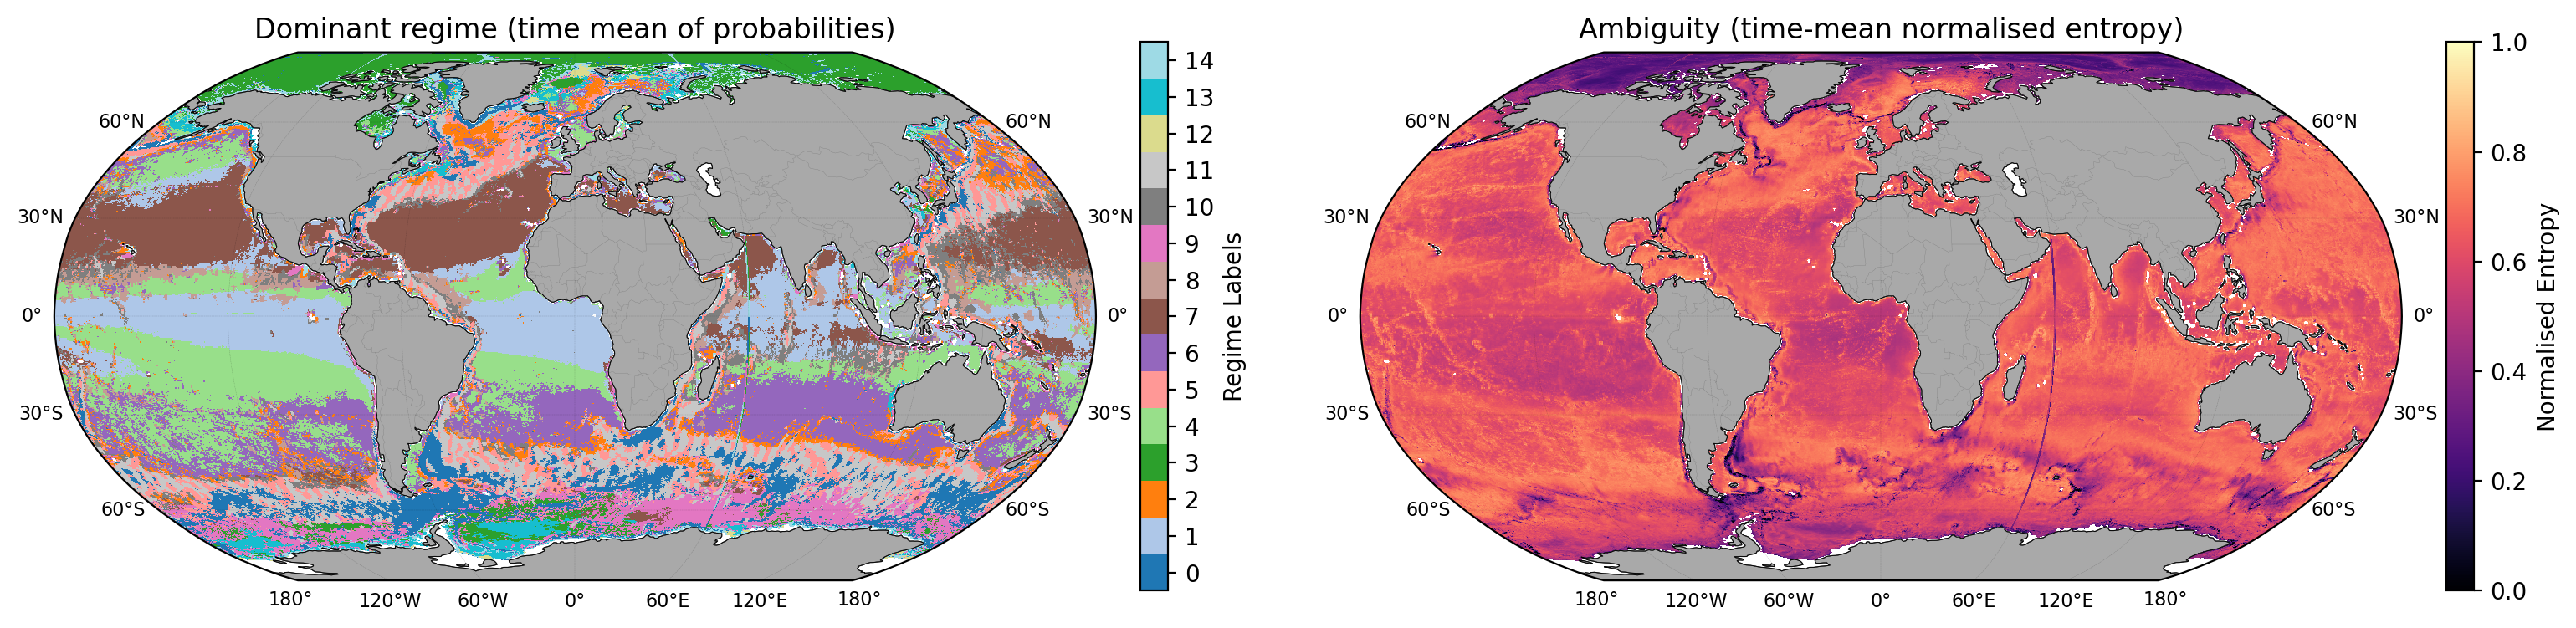

In [51]:
# A discrete colormap with exactly K colours, so neighbouring regime indices
# stay distinguishable and the colourbar ticks land on the integers.
REGIME_CMAP = plt.get_cmap("tab20", K)
REGIME_KW = dict(cmap=REGIME_CMAP, vmin=-0.5, vmax=K - 0.5,
                 cbar_kwargs={"label": "Regime Labels", "shrink": 0.8,
                              "pad": 0.035, "ticks": np.arange(K)})

def plot_map(da, ax=None, title="", cbar_label="", figsize=(9, 4.2), pad=0.025, **kwargs):
    """One map, with cartopy when it is installed and plain axes when it is not.

    Extra keyword arguments go straight to `DataArray.plot`, so pass
    `**REGIME_KW` for a regime field and `cmap=`/`vmin=`/`vmax=` for the rest.
    """
    if ax is None:
        kw = {"projection": ccrs.Robinson(central_longitude=180)} if HAS_CARTOPY else {}
        fig, ax = plt.subplots(figsize=figsize, subplot_kw=kw)
    if HAS_CARTOPY:
        kwargs.setdefault("transform", ccrs.PlateCarree())
    kwargs.setdefault("cbar_kwargs", {"label": cbar_label, "shrink": 0.8, "pad": pad})
    da.plot(ax=ax, **kwargs)
    if HAS_CARTOPY:
        ax.coastlines(linewidth=0.4)
    ax.set_title(title)
    ax.grid(False)
    return ax

prob_mean = pred["regime_prob"].mean("time")
ocean2d = prob_mean.notnull().any("regime")
dominant = prob_mean.fillna(-1.0).argmax("regime").where(ocean2d)
mean_entropy = entropy.mean("time")

kw = {"subplot_kw": {"projection": ccrs.Robinson(central_longitude=0)}} if HAS_CARTOPY else {}
fig, axes = plt.subplots(1, 2, figsize=(16, 4.4), dpi=200, **kw)
plot_map(dominant, ax=axes[0], title="Dominant regime (time mean of probabilities)", 
         pad=0.02, **REGIME_KW)
add_map_features(axes[0], draw_countries=True, draw_labels=True, right=True)
axes[0].add_feature(cfeature.COASTLINE, linewidth=0.3, zorder=4)
#
plot_map(mean_entropy, ax=axes[1], title="Ambiguity (time-mean normalised entropy)", 
         pad=0.035, cmap="magma", vmin=0, vmax=1, cbar_label="Normalised Entropy")
add_map_features(axes[1], draw_countries=True, draw_labels=True, right=True)
axes[1].add_feature(cfeature.COASTLINE, linewidth=0.3, zorder=4)
plt.show()

The left panel is only trustworthy where the right panel is dark. Read alone,
the regime map invites over-interpretation of exactly the regions the model is
least sure about.

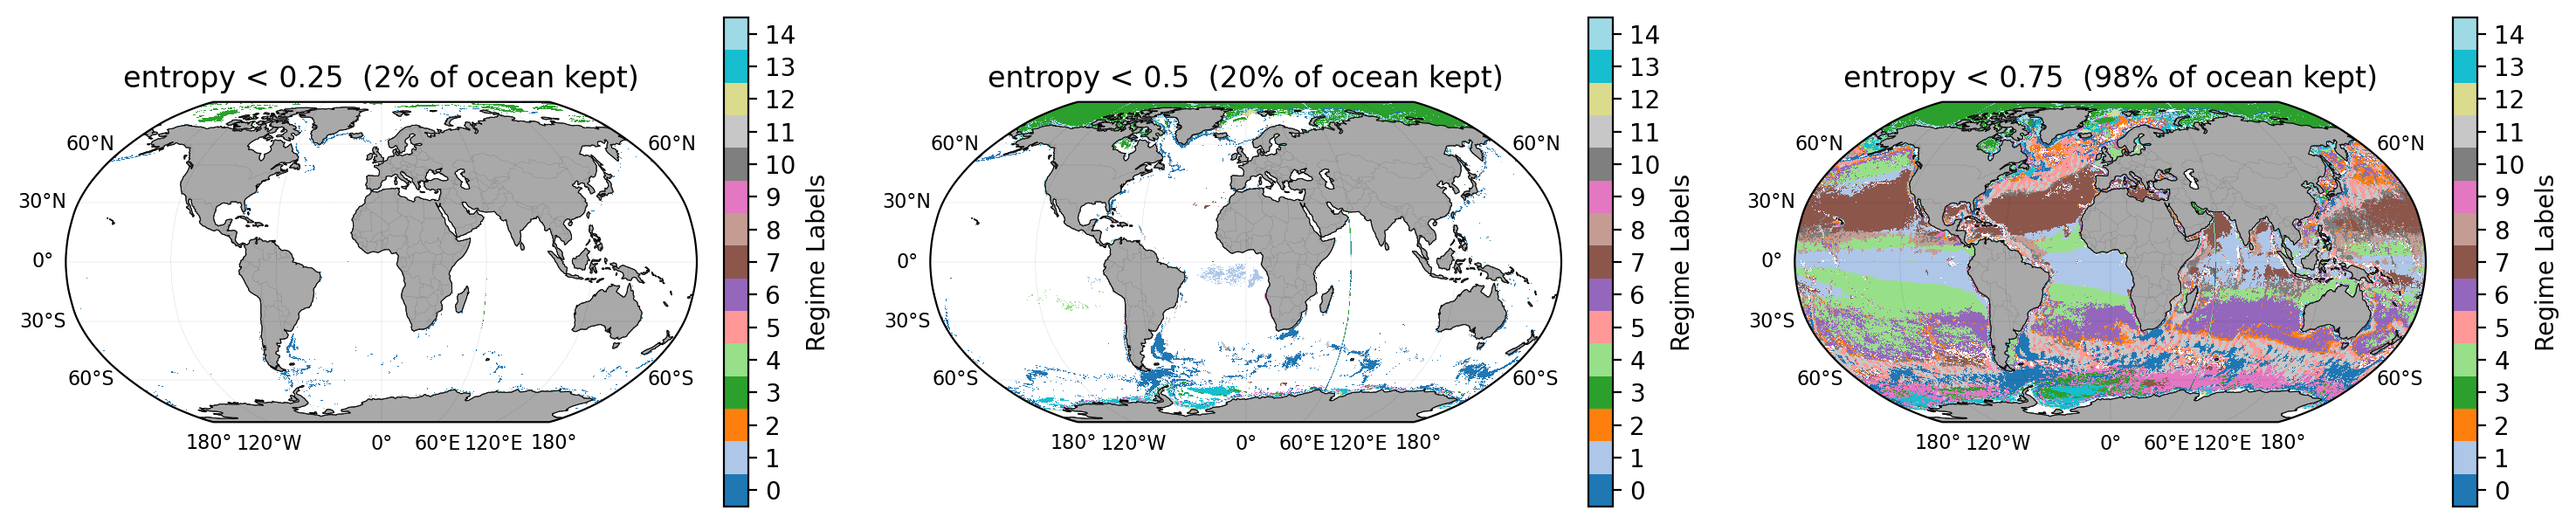

In [58]:
# The same field with the ambiguous cells removed, at three thresholds.
THRESHOLDS = [0.25, 0.5, 0.75]
kw = {"subplot_kw": {"projection": ccrs.Robinson(central_longitude=0)}} if HAS_CARTOPY else {}
fig, axes = plt.subplots(1, len(THRESHOLDS), figsize=(5 * len(THRESHOLDS), 3.8), dpi=200, **kw)
for ax, thr in zip(np.atleast_1d(axes), THRESHOLDS):
    kept = dominant.where(mean_entropy < thr)
    frac = float((mean_entropy < thr).where(ocean2d).mean())
    plot_map(kept, ax=ax, title=f"entropy < {thr}  ({frac:.0%} of ocean kept)", **REGIME_KW)
    add_map_features(ax, draw_countries=True, draw_labels=True, right=False)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.3, zorder=4)
plt.show()

How much of the map survives each threshold is itself a result. A regime map
that mostly disappears at `entropy < 0.5` is not a classification of the ocean;
it is a classification of a few well-defined regions surrounded by transitional
dynamics — which is a finding, not a failure.

## Is the entropy actually telling the truth?

This is the claim the whole design rests on: **low entropy should mean more
often right**. It is testable wherever labels exist, and worth testing before
any entropy threshold is used to mask a figure in a paper.

If accuracy turns out to be flat across the entropy deciles, the entropy is not
a usable reliability signal for this run and the masked maps above mean nothing.

In [35]:
if HAS_LABELS:
    t = truth.values
    p = pred["regime_pred"].values
    e = entropy.values
    c = pred["regime_confidence"].values

    m = np.isfinite(t) & np.isfinite(p)
    t_v, p_v, e_v, c_v = t[m], p[m], e[m], c[m]
    correct = (t_v == p_v)

    print(f"scored cells       : {m.sum():,}")
    print(f"accuracy           : {correct.mean():.4f}")

    # Deciles of entropy: accuracy should fall monotonically as entropy rises.
    edges = np.quantile(e_v, np.linspace(0, 1, 11))
    edges[-1] += 1e-9
    binned = np.digitize(e_v, edges[1:-1])
    decile = pd.DataFrame({
        "mean_entropy": [e_v[binned == i].mean() for i in range(10)],
        "accuracy": [correct[binned == i].mean() for i in range(10)],
        "n": [int((binned == i).sum()) for i in range(10)],
    }, index=pd.Index(range(1, 11), name="entropy decile"))
    display(decile.style.format({"mean_entropy": "{:.3f}", "accuracy": "{:.3f}",
                                 "n": "{:,}"}))

    spread = decile["accuracy"].iloc[0] - decile["accuracy"].iloc[-1]
    print(f"\naccuracy, lowest vs highest entropy decile: "
          f"{decile['accuracy'].iloc[0]:.3f} vs {decile['accuracy'].iloc[-1]:.3f} "
          f"(spread {spread:+.3f})")
    print("Entropy is informative." if spread > 0.05 else
          "WARNING: entropy barely separates right from wrong in this run.")
else:
    print("Skipped - no labels in this dataset.")

scored cells       : 118,261,920
accuracy           : 0.4321


,mean_entropy,accuracy,n
entropy decile,,,
1,0.162,0.885,"11,826,191"
2,0.393,0.617,"11,826,192"
3,0.509,0.495,"11,826,187"
4,0.562,0.432,"11,826,191"
5,0.604,0.395,"11,826,170"
6,0.643,0.361,"11,826,220"
7,0.679,0.331,"11,826,172"
8,0.715,0.302,"11,826,198"
9,0.755,0.273,"11,826,199"



accuracy, lowest vs highest entropy decile: 0.885 vs 0.231 (spread +0.654)
Entropy is informative.


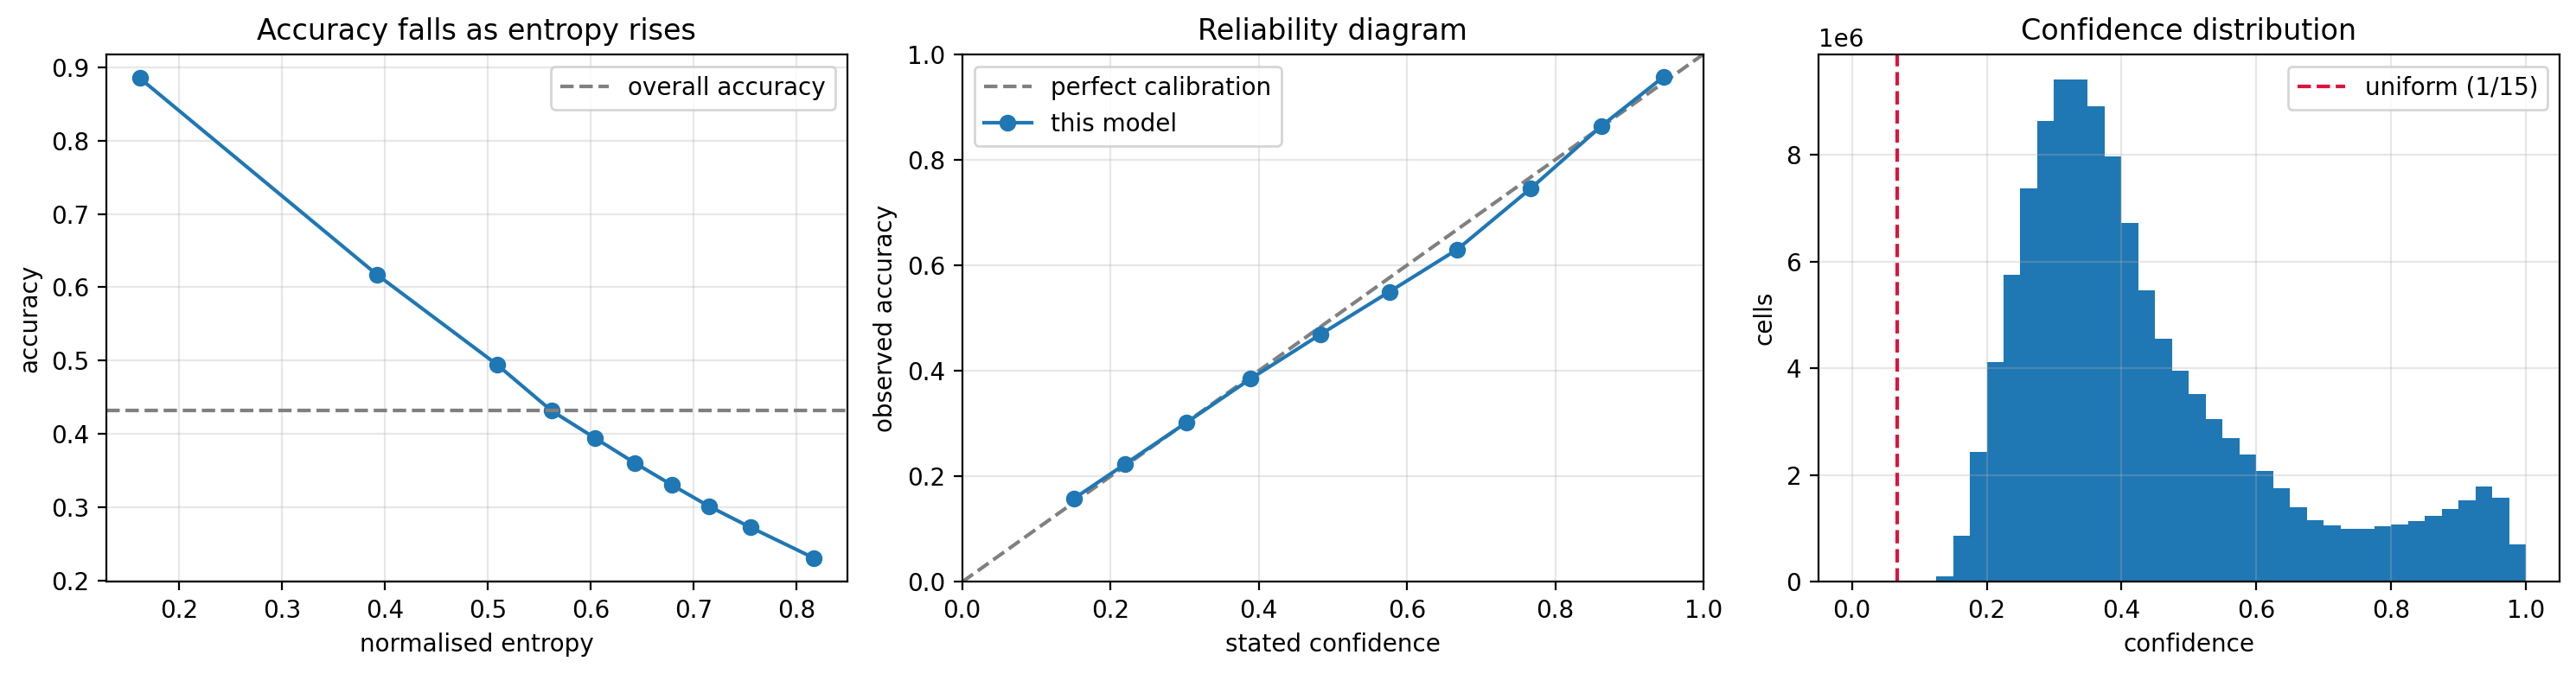

expected calibration error: 0.0083   (0 = stated probabilities match observed frequencies)
Above the diagonal = under-confident; below = over-confident.


In [36]:
if HAS_LABELS:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), dpi=200)

    # (a) accuracy vs entropy
    axes[0].plot(decile["mean_entropy"], decile["accuracy"], "o-")
    axes[0].axhline(correct.mean(), ls="--", c="grey", label="overall accuracy")
    axes[0].set(xlabel="normalised entropy", ylabel="accuracy",
                title="Accuracy falls as entropy rises")
    axes[0].legend()

    # (b) reliability: is a stated probability of 0.8 right 80% of the time?
    bins = np.linspace(1.0 / K, 1.0, 11)
    idx = np.clip(np.digitize(c_v, bins[1:-1]), 0, len(bins) - 2)
    rel = pd.DataFrame({
        "confidence": [c_v[idx == i].mean() if (idx == i).any() else np.nan
                       for i in range(len(bins) - 1)],
        "accuracy": [correct[idx == i].mean() if (idx == i).any() else np.nan
                     for i in range(len(bins) - 1)],
        "n": [int((idx == i).sum()) for i in range(len(bins) - 1)],
    }).dropna()
    axes[1].plot([0, 1], [0, 1], ls="--", c="grey", label="perfect calibration")
    axes[1].plot(rel["confidence"], rel["accuracy"], "o-", label="this model")
    axes[1].set(xlabel="stated confidence", ylabel="observed accuracy",
                title="Reliability diagram", xlim=(0, 1), ylim=(0, 1))
    axes[1].legend()

    # Expected calibration error: mean |confidence - accuracy|, weighted by count.
    ece = float((rel["n"] * (rel["confidence"] - rel["accuracy"]).abs()).sum() / rel["n"].sum())

    # (c) where the confidence mass sits
    axes[2].hist(c_v, bins=40, range=(0, 1))
    axes[2].axvline(1.0 / K, ls="--", c="crimson", label=f"uniform (1/{K})")
    axes[2].set(xlabel="confidence", ylabel="cells", title="Confidence distribution")
    axes[2].legend()
    plt.show()

    print(f"expected calibration error: {ece:.4f}   "
          "(0 = stated probabilities match observed frequencies)")
    print("Above the diagonal = under-confident; below = over-confident.")
else:
    print("Skipped - no labels in this dataset.")

Over-confidence is the failure mode to watch for. A model whose reliability
curve sits below the diagonal is claiming more certainty than it earns, and its
low-entropy regions are not as safe as they look.

### Per-regime skill

Class-balanced training buys skill on the rare regimes at some cost to the
common ones. This table is where that trade-off becomes visible, and it is the
one to look at before changing `--class-weights`.

In [37]:
if HAS_LABELS:
    from sklearn.metrics import confusion_matrix, balanced_accuracy_score

    cm = confusion_matrix(t_v.astype(int), p_v.astype(int), labels=np.arange(K))
    recall = np.divide(np.diag(cm), cm.sum(1), out=np.full(K, np.nan),
                       where=cm.sum(1) > 0)
    precision = np.divide(np.diag(cm), cm.sum(0), out=np.full(K, np.nan),
                          where=cm.sum(0) > 0)

    per_regime = pd.DataFrame({
        "support": cm.sum(1),
        "share_true": cm.sum(1) / cm.sum(),
        "share_pred": cm.sum(0) / cm.sum(),
        "recall": recall,
        "precision": precision,
        "mean_entropy": [float(e_v[t_v == k].mean()) if (t_v == k).any() else np.nan
                         for k in range(K)],
    }, index=pd.Index(range(K), name="regime"))

    print(f"balanced accuracy: {balanced_accuracy_score(t_v.astype(int), p_v.astype(int)):.4f}")
    display(per_regime.style.format({"support": "{:,}", "share_true": "{:.3f}",
                                     "share_pred": "{:.3f}", "recall": "{:.3f}",
                                     "precision": "{:.3f}", "mean_entropy": "{:.3f}"})
                       .background_gradient(subset=["recall"], cmap="RdYlGn", vmin=0, vmax=1))
else:
    print("Skipped - no labels in this dataset.")

balanced accuracy: 0.4770


,support,share_true,share_pred,recall,precision,mean_entropy
regime,,,,,,
0,0,0.000,0.000,nan,nan,nan
1,"9,240,524",0.081,0.067,0.559,0.679,0.458
2,"13,358,914",0.117,0.097,0.384,0.462,0.626
3,"9,893,000",0.087,0.058,0.222,0.334,0.693
4,"8,876,815",0.078,0.081,0.900,0.868,0.285
5,"11,674,226",0.102,0.100,0.419,0.427,0.624
6,"8,165,437",0.072,0.076,0.368,0.345,0.652
7,"9,503,817",0.083,0.095,0.385,0.336,0.669
8,"9,736,787",0.085,0.103,0.466,0.386,0.642


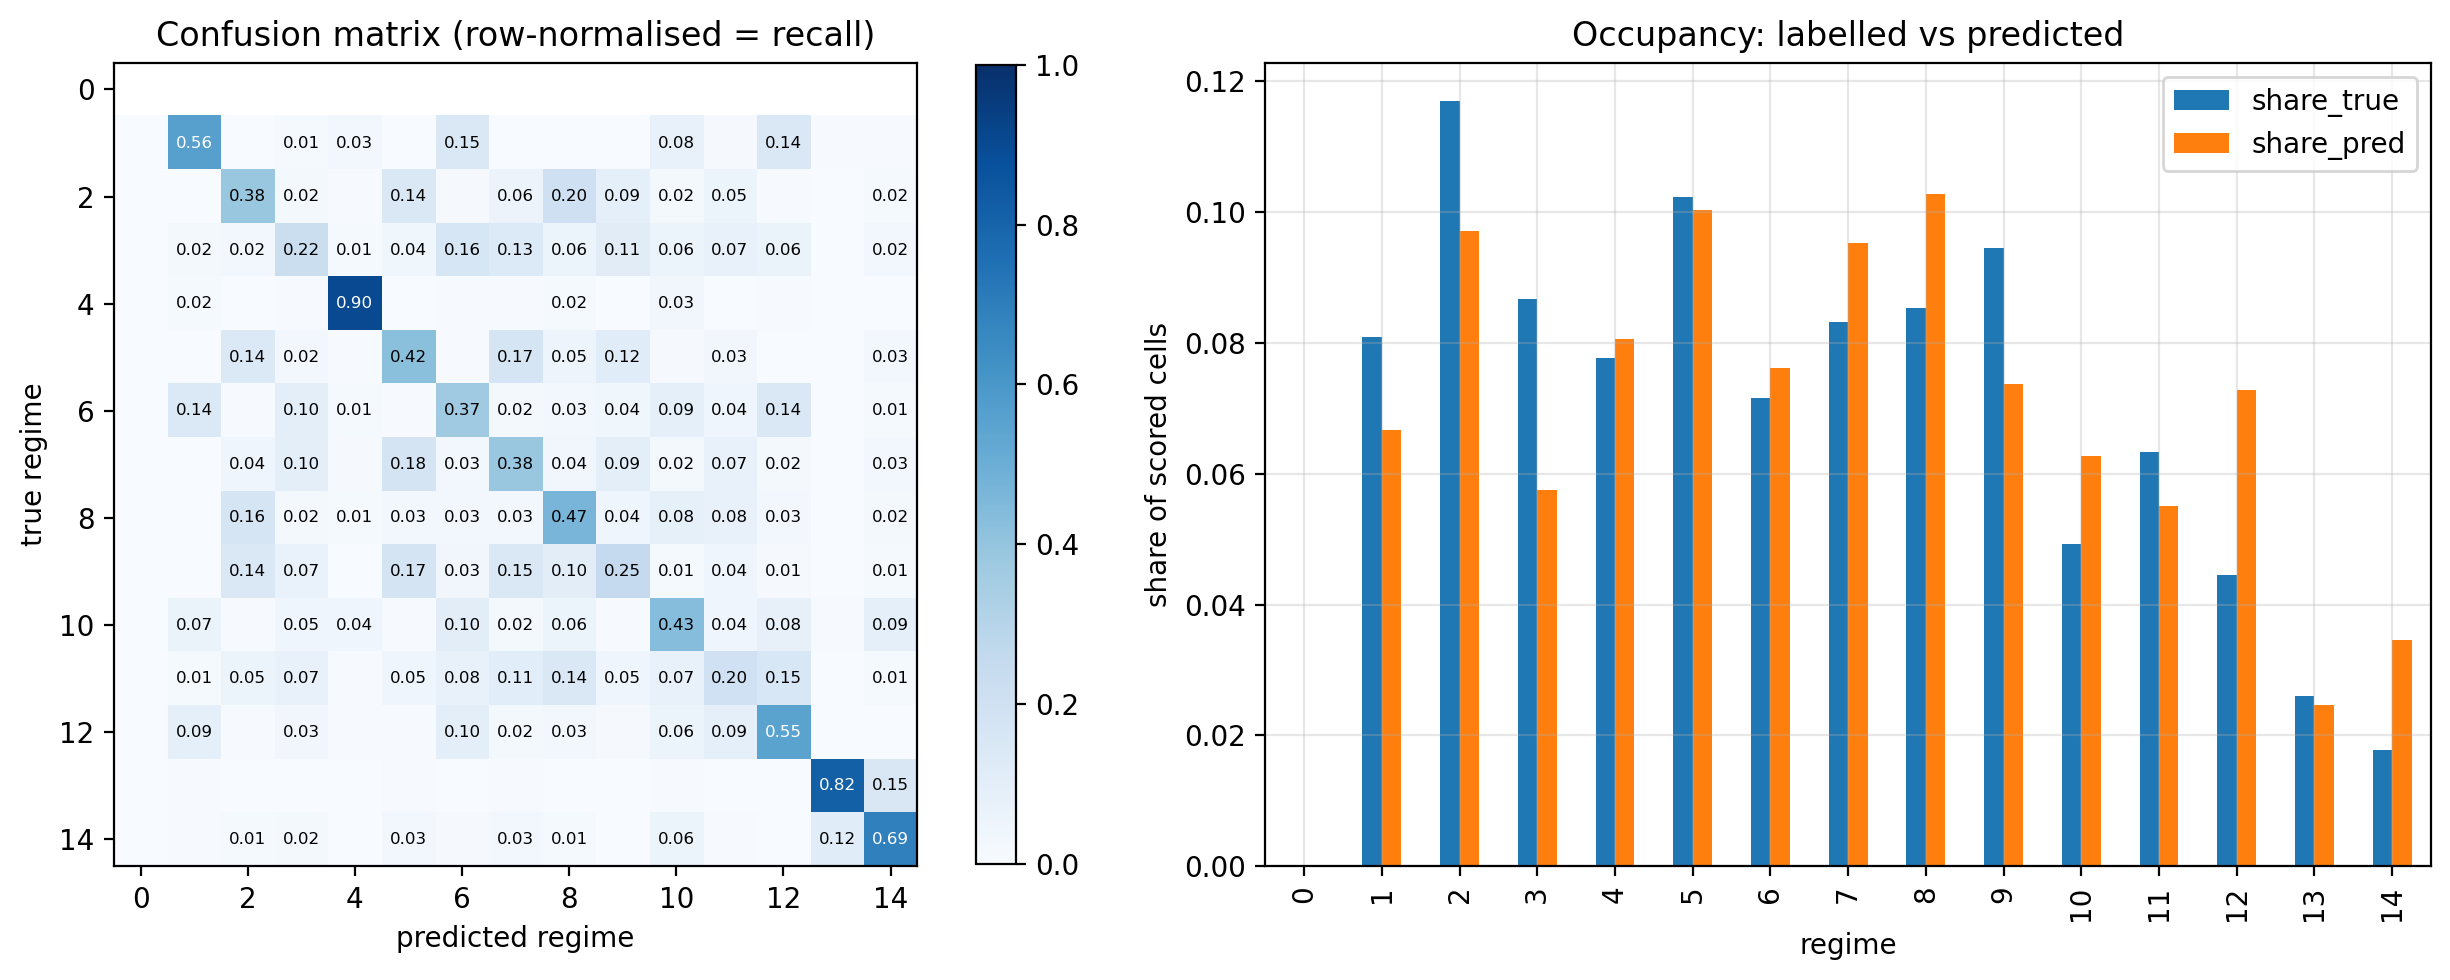

Most confused pair: true regime 2 predicted as 8 (20.4% of regime 2).


In [40]:
if HAS_LABELS:
    with np.errstate(invalid="ignore"):
        cm_norm = cm / cm.sum(1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=200)
    im = axes[0].imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    axes[0].set(xlabel="predicted regime", ylabel="true regime",
                title="Confusion matrix (row-normalised = recall)")
    fig.colorbar(im, ax=axes[0], shrink=0.995)
    if K <= 20:
        for i in range(K):
            for j in range(K):
                if np.isfinite(cm_norm[i, j]) and cm_norm[i, j] > 0.01:
                    axes[0].text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center",
                                 fontsize=6,
                                 color="white" if cm_norm[i, j] > 0.5 else "black")
    axes[0].grid(False)

    w = per_regime[["share_true", "share_pred"]]
    w.plot.bar(ax=axes[1], title="Occupancy: labelled vs predicted")
    axes[1].set(xlabel="regime", ylabel="share of scored cells")
    plt.show()

    off = cm_norm.copy()
    np.fill_diagonal(off, 0.0)
    i, j = np.unravel_index(np.nanargmax(off), off.shape)
    print(f"Most confused pair: true regime {i} predicted as {j} "
          f"({off[i, j]:.1%} of regime {i}).")
else:
    print("Skipped - no labels in this dataset.")

Systematic confusion between two regimes is worth chasing in the physics rather
than in the hyper-parameters: neighbouring BV regimes that share a dominant
balance term are genuinely hard to separate from the nine budget terms alone,
and the model saying so is informative.

## Occupancy, persistence and ambiguity through time

One correction to the obvious approach: a plain `mean(("lat", "lon"))` over a
regular lat/lon grid **over-weights the poles**, where the cells are far
smaller. Every spatial average below is weighted by `cos(lat)`, so the numbers
are ocean-area fractions rather than cell-count fractions.

In [42]:
def _fmt_day(value) -> str:
    """
    Format a single time coordinate value as YYYY-MM-DD.

    Handles both numpy datetime64 (standard calendars) and cftime objects,
    which CM4X output uses for non-standard calendars such as noleap. cftime
    values are plain Python objects, so np.datetime_as_string rejects them.
    """
    if isinstance(value, np.datetime64):
        return str(np.datetime_as_string(value, unit="D"))
    return str(value)[:10]

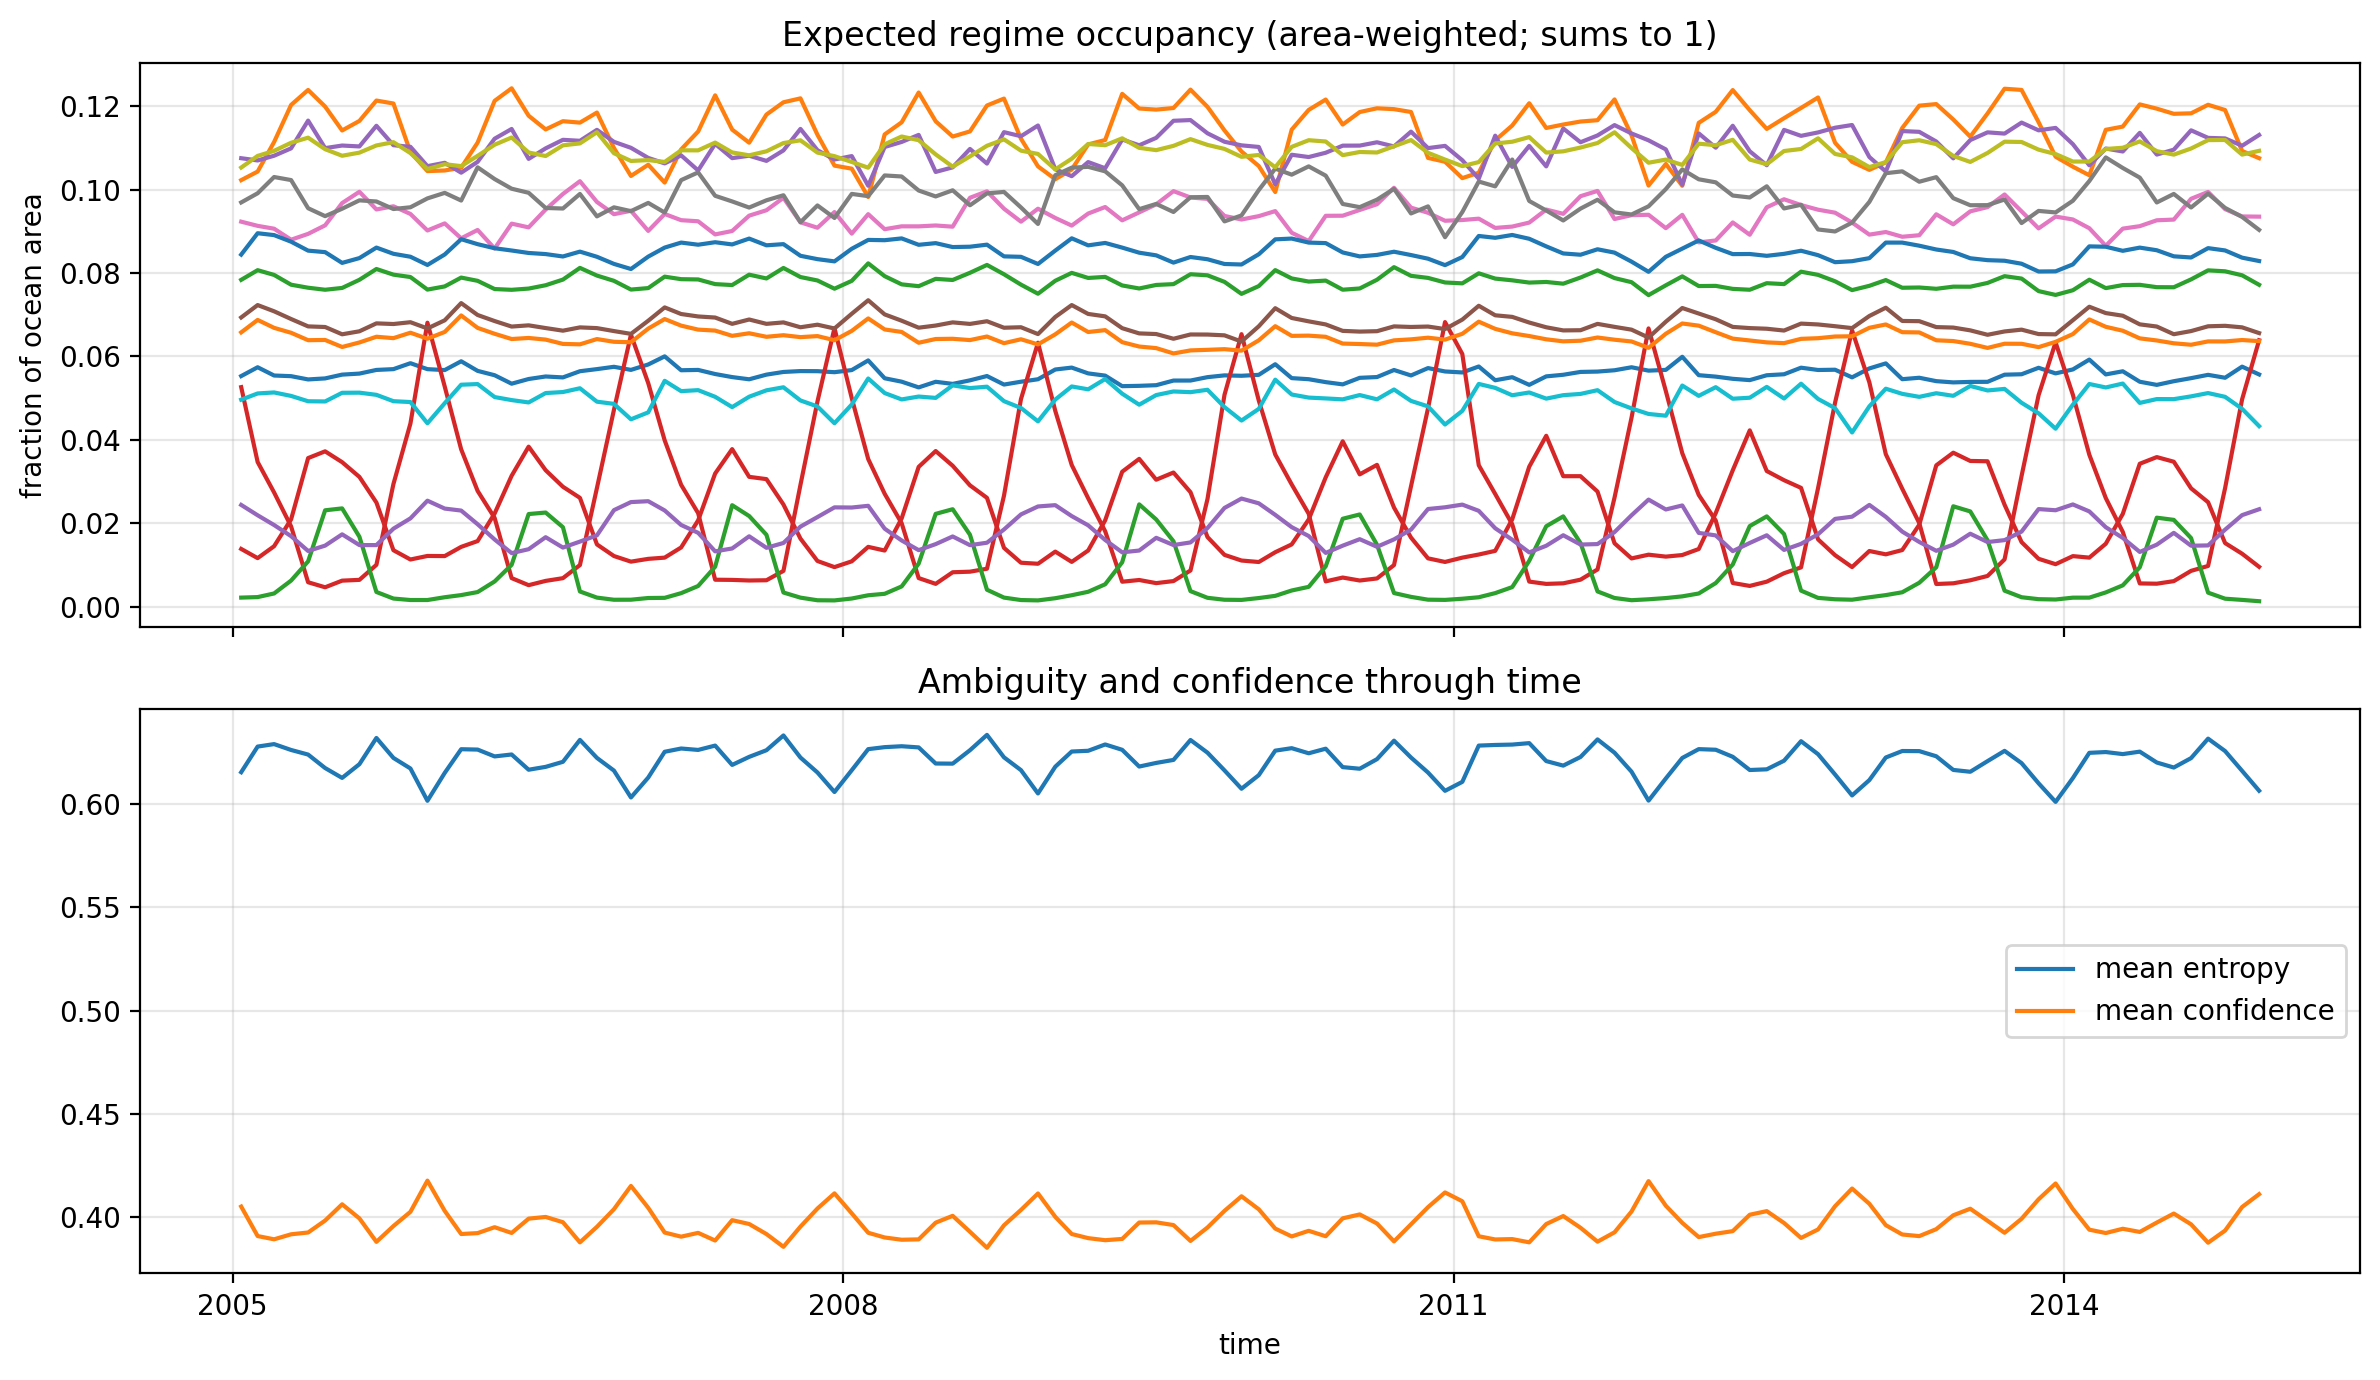

Most ambiguous months:
  2008-09-16  entropy 0.6333
  2007-09-16  entropy 0.6330
  2005-09-16  entropy 0.6318
  2014-09-16  entropy 0.6315
  2011-09-16  entropy 0.6311


In [43]:
weights = np.cos(np.deg2rad(pred["lat"]))
weights.name = "area_weight"

# Expected occupancy: area-weighted mean probability, so it sums to 1 by construction.
occupancy = pred["regime_prob"].weighted(weights).mean(("lat", "lon"))
ambiguity_ts = entropy.weighted(weights).mean(("lat", "lon"))
confidence_ts = pred["regime_confidence"].weighted(weights).mean(("lat", "lon"))

fig, axes = plt.subplots(2, 1, figsize=(12, 7), dpi=200, sharex=True)
occupancy.plot.line(x="time", ax=axes[0], add_legend=(K <= 12))
axes[0].set(title="Expected regime occupancy (area-weighted; sums to 1)",
            ylabel="fraction of ocean area", xlabel="")
ambiguity_ts.plot(ax=axes[1], label="mean entropy")
confidence_ts.plot(ax=axes[1], label="mean confidence")
axes[1].set(title="Ambiguity and confidence through time", ylabel="", xlabel="time")
axes[1].legend()
plt.show()

print("Most ambiguous months:")
for ts in ambiguity_ts.sortby(ambiguity_ts, ascending=False).time.values[:5]:
    print(f"  {_fmt_day(ts)}  "
          f"entropy {float(ambiguity_ts.sel(time=ts)):.4f}")

month-to-month persistence: 41.1% of cells keep their regime


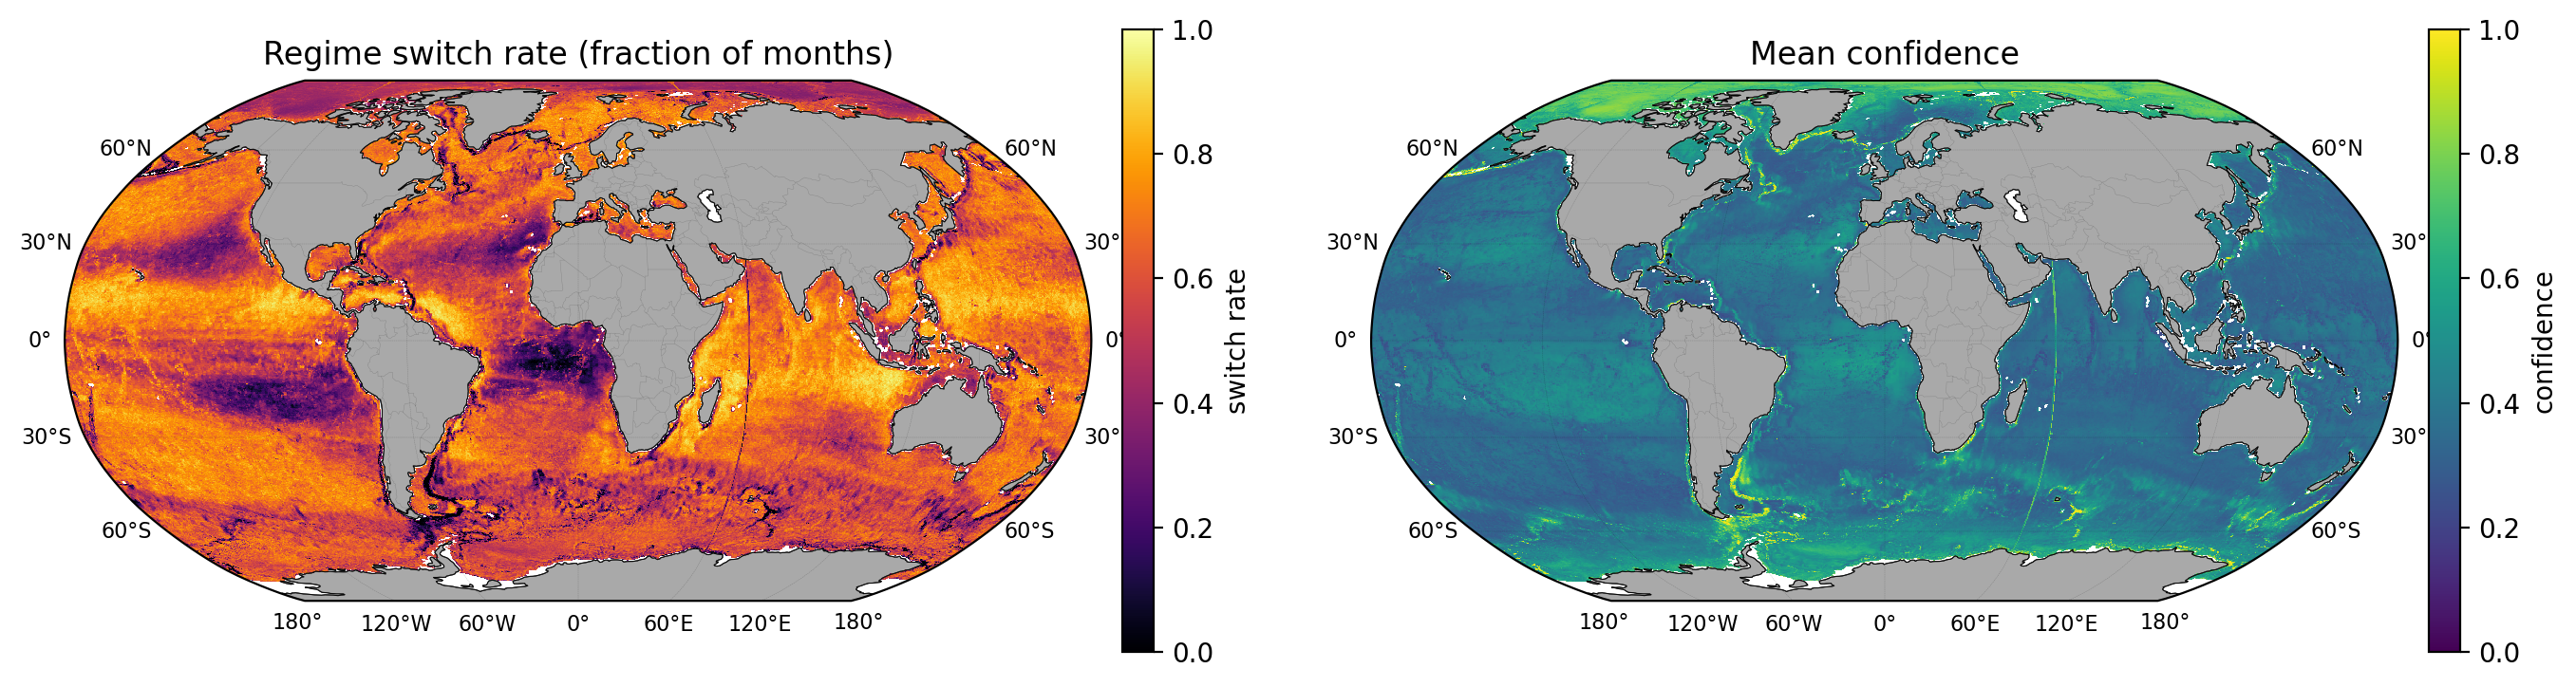

In [59]:
# Persistence: how often a cell keeps its regime from one month to the next.
rp = pred["regime_pred"].values
a, b = rp[:-1], rp[1:]
both = np.isfinite(a) & np.isfinite(b)
persistence = float((a[both] == b[both]).mean())

# Per-cell switch rate, as a map.
switch = np.full(rp.shape[1:], np.nan, dtype=np.float32)
cnt = both.sum(0)
with np.errstate(invalid="ignore"):
    switch_frac = (a != b).astype(np.float32)
    switch_frac[~both] = 0.0
    switch = np.where(cnt > 0, switch_frac.sum(0) / np.maximum(cnt, 1), np.nan)
switch_da = xr.DataArray(switch, dims=("lat", "lon"),
                         coords={"lat": pred["lat"], "lon": pred["lon"]},
                         name="switch_rate")

print(f"month-to-month persistence: {persistence:.1%} of cells keep their regime")

kw = {"subplot_kw": {"projection": ccrs.Robinson(central_longitude=0)}} if HAS_CARTOPY else {}
fig, axes = plt.subplots(1, 2, figsize=(14, 4.4), dpi=200, **kw)
plot_map(switch_da, ax=axes[0], title="Regime switch rate (fraction of months)",
         cmap="inferno", vmin=0, vmax=1, cbar_label="switch rate")
add_map_features(axes[0], draw_countries=True, draw_labels=True, right=True)
axes[0].add_feature(cfeature.COASTLINE, linewidth=0.3, zorder=4)
#
plot_map(pred["regime_confidence"].mean("time"), ax=axes[1],
         title="Mean confidence", cmap="viridis", vmin=0, vmax=1, cbar_label="confidence")
add_map_features(axes[1], draw_countries=True, draw_labels=True, right=True)
axes[1].add_feature(cfeature.COASTLINE, linewidth=0.3, zorder=4)

plt.show()

The switch-rate map and the entropy map answer different questions and usually
disagree somewhere interesting. Entropy is *instantaneous* uncertainty — the
model is unsure this month. A high switch rate is *temporal* variability — the
model is confident each month but keeps changing its mind. Cells that are
confident yet volatile are the ones genuinely moving between regimes, and they
are the physically interesting ones.

## Save what you derived

The prediction store is the pipeline's output; this is the notebook's. Keep it
separate from `predictions/` so a rerun of the job never overwrites it.

In [64]:
analysis = xr.Dataset({
    "dominant_regime": dominant,
    "mean_entropy": mean_entropy,
    "mean_confidence": pred["regime_confidence"].mean("time"),
    "switch_rate": switch_da,
    "occupancy": occupancy,
    "ambiguity_ts": ambiguity_ts,
})
analysis.attrs = {
    "created_from": str(PRED_STORE),
    "checkpoint": str(CKPT),
    "tag": TAG,
    "n_regimes": K,
    "note": "Spatial means are area-weighted by cos(lat).",
}

out_nc = SCRATCH / f"{TAG}_analysis.nc"
analysis.to_netcdf(out_nc)
print(f"written: {out_nc}")

if HAS_LABELS:
    per_regime.to_csv(SCRATCH / f"{TAG}_per_regime_skill.csv")
    decile.to_csv(SCRATCH / f"{TAG}_accuracy_vs_entropy.csv")
    print(f"written: {SCRATCH / f'{TAG}_per_regime_skill.csv'}")
    print(f"written: {SCRATCH / f'{TAG}_accuracy_vs_entropy.csv'}")

written: /group/maikesgrp/laique/PPAN/CM4X/NN4X/outputs/notebook_outputs/bvb_mlp_h256x128x64x32_k15_2005_2011_analysis.nc
written: /group/maikesgrp/laique/PPAN/CM4X/NN4X/outputs/notebook_outputs/bvb_mlp_h256x128x64x32_k15_2005_2011_per_regime_skill.csv
written: /group/maikesgrp/laique/PPAN/CM4X/NN4X/outputs/notebook_outputs/bvb_mlp_h256x128x64x32_k15_2005_2011_accuracy_vs_entropy.csv
